## TEAM 5 EVIDENCE 1

 - Luis Diego Dominguez Larrieta - A01275640 
 - Jesús Emiliano Morales Villela - A00840087 
 - David Alexander Lopez Guzman - A00835935 
 - Jose Dolores Gomez Soto - A01712281 
 - Ignacio Xavier Chávez Quiroz - A00574357

## Database used in this notebook

For this notebook, we used the dataset generated in Activity 4.1 after the data preparation process.

Instead of working with the original raw transactional data, we used a processed version where the information was aggregated by **day, product, and branch**. This means that each row in the dataset represents the total quantity sold of a specific product, in a specific branch, on a given day.

This transformation was performed during the previous stages of the project in order to simplify the dataset and make it more suitable for analysis and modeling. By aggregating the data in this way, the dataset becomes more compact and easier to interpret, while still preserving the key information about sales behavior.

Therefore, the database used in this notebook corresponds to a structured and processed version of the original data, which allows us to perform descriptive statistical analysis in a more efficient and meaningful way.

In [17]:
import pandas as pd

GITHUB_RAW_URL = "https://raw.githubusercontent.com/DiegoLarrieta/PanemReto/main/data/processed/top5_per_branch.csv"

df = pd.read_csv(GITHUB_RAW_URL, low_memory=False, skipinitialspace=True)
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

df.head(10)

,sucursal,operating_date,item,quantity,day_name,week_number,tavg,cold_or_warm,holiday_type,holidays,qty_roll_1,qty_roll_3,qty_roll_7,qty_roll_15,qty_roll_30,qty_roll_60,qty_roll_90,qty_roll_180,qty_roll_365
0,Panem - Carreta,2022-02-18,CONCHA CHOCOLATE,13.0,viernes,7,13.5,cold,No holiday,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Panem - Carreta,2022-02-19,CONCHA CHOCOLATE,4.0,sábado,7,12.9,cold,No holiday,False,13.0,13.0,13.0,13.0,13.0,13.0,13.0,13.0,13.0
2,Panem - Carreta,2022-02-21,CONCHA CHOCOLATE,7.0,lunes,8,21.6,cold,No holiday,False,0.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0
3,Panem - Carreta,2022-02-22,CONCHA CHOCOLATE,30.0,martes,8,25.8,warm,No holiday,False,7.0,11.0,24.0,24.0,24.0,24.0,24.0,24.0,24.0
4,Panem - Carreta,2022-02-23,CONCHA CHOCOLATE,13.0,miércoles,8,17.2,cold,No holiday,False,30.0,37.0,54.0,54.0,54.0,54.0,54.0,54.0,54.0
5,Panem - Carreta,2022-02-26,CONCHA CHOCOLATE,7.0,sábado,8,7.8,cold,No holiday,False,0.0,13.0,54.0,67.0,67.0,67.0,67.0,67.0,67.0
6,Panem - Carreta,2022-02-28,CONCHA CHOCOLATE,16.0,lunes,9,12.6,cold,No holiday,False,0.0,7.0,57.0,74.0,74.0,74.0,74.0,74.0,74.0
7,Panem - Carreta,2022-03-01,CONCHA CHOCOLATE,11.0,martes,9,14.4,cold,No holiday,False,16.0,23.0,66.0,90.0,90.0,90.0,90.0,90.0,90.0
8,Panem - Carreta,2022-03-02,CONCHA CHOCOLATE,23.0,miércoles,9,15.8,cold,No holiday,False,11.0,27.0,47.0,101.0,101.0,101.0,101.0,101.0,101.0
9,Panem - Carreta,2022-03-03,CONCHA CHOCOLATE,16.0,jueves,9,18.5,cold,No holiday,False,23.0,50.0,57.0,124.0,124.0,124.0,124.0,124.0,124.0


## 4 Handling missing values

In this project, missing values were not mainly identified as empty cells inside existing rows, but rather as missing daily records after aggregating the data by product and date.

Once the dataset was transformed into daily sales per product, a missing value situation appeared whenever a product had no registered sale on a specific day. In those cases, the row for that product-day combination did not exist in the dataset. Therefore, the absence of a record was interpreted as missing information in the daily product time series.

To address this, the dataset was completed so that each top-5 product had a record for every day in the 365-day period. When a product had no sale on a given day, the quantity sold was assigned a value of **0**. This approach was appropriate because the engineered variables depended on the calendar day rather than only on observed sales, so a complete daily structure was necessary for the analysis.

The interpretation of these missing records depends on the pattern:
- if the absence occurred only for one product on a given day, it was interpreted as a day with zero sales for that specific product;
- if the absence occurred across all products on the same day, it was interpreted as a day in which the store most likely did not operate.

This treatment was selected because it preserves the continuity of the daily product series and avoids incorrectly treating non-sale days as unknown values. In this context, assigning a quantity of 0 is more appropriate than imputing with mean, median, or interpolation, since the lack of a row does not represent uncertainty, but rather the absence of sales.

In [18]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(4)

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing (%)":    missing_pct,
})

print(f"Total rows: {len(df)}")
print(f"Total missing values across all columns: {missing_count.sum()}\n")
missing_summary

Total rows: 33118
Total missing values across all columns: 0



,Missing Values,Missing (%)
sucursal,0,0.0
operating_date,0,0.0
item,0,0.0
quantity,0,0.0
day_name,0,0.0
week_number,0,0.0
tavg,0,0.0
cold_or_warm,0,0.0
holiday_type,0,0.0
holidays,0,0.0


## 5 Variable Classification and Data Types

In this section, each variable in the dataset is classified according to its **statistical type** (nominal, ordinal, discrete, or continuous) and its **data type in pandas** (such as object, int64, float64, or datetime64).

This step is important to verify that the variables are stored correctly before performing the descriptive statistical analysis. In particular, quantitative variables must be stored as numeric values, and date variables must not appear as strings or objects.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33118 entries, 0 to 33117
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sucursal        33118 non-null  object 
 1   operating_date  33118 non-null  object 
 2   item            33118 non-null  object 
 3   quantity        33118 non-null  float64
 4   day_name        33118 non-null  object 
 5   week_number     33118 non-null  int64  
 6   tavg            33118 non-null  float64
 7   cold_or_warm    33118 non-null  object 
 8   holiday_type    33118 non-null  object 
 9   holidays        33118 non-null  object 
 10  qty_roll_1      33118 non-null  float64
 11  qty_roll_3      33118 non-null  float64
 12  qty_roll_7      33118 non-null  float64
 13  qty_roll_15     33118 non-null  float64
 14  qty_roll_30     33118 non-null  float64
 15  qty_roll_60     33118 non-null  float64
 16  qty_roll_90     33118 non-null  float64
 17  qty_roll_180    33118 non-null 

In [20]:
stat_types = {
    "sucursal":       "nominal",
    "operating_date": "temporal",
    "item":           "nominal",
    "quantity":       "discrete",
    "day_name":       "nominal",
    "week_number":    "discrete",
    "tavg":           "continuous",
    "cold_or_warm":   "nominal",
    "holiday_type":   "nominal",
    "holidays":       "nominal",
    "qty_roll_1":     "discrete",
    "qty_roll_3":     "discrete",
    "qty_roll_7":     "discrete",
    "qty_roll_15":    "discrete",
    "qty_roll_30":    "discrete",
    "qty_roll_60":    "discrete",
    "qty_roll_90":    "discrete",
    "qty_roll_180":   "discrete",
    "qty_roll_365":   "discrete",
}

variable_summary = pd.DataFrame({
    "Variable":         list(df.columns),
    "Pandas dtype":     list(df.dtypes.astype(str).values),
    "Statistical type": [stat_types[c] for c in df.columns],
})

variable_summary

,Variable,Pandas dtype,Statistical type
0,sucursal,object,nominal
1,operating_date,object,temporal
2,item,object,nominal
3,quantity,float64,discrete
4,day_name,object,nominal
5,week_number,int64,discrete
6,tavg,float64,continuous
7,cold_or_warm,object,nominal
8,holiday_type,object,nominal
9,holidays,object,nominal


## Verification of data types

After classifying each variable by its statistical type, the pandas data types were reviewed to confirm that the variables were stored correctly.

This step is important to ensure that:
- date variables are stored in datetime format,
- quantitative variables are stored as numeric values,
- categorical variables are stored as object, string, or boolean values.

This verification helps prevent errors in the descriptive statistical analysis and ensures that numeric variables do not contain strings or incorrectly formatted dates.

In [21]:
df["operating_date"] = pd.to_datetime(df["operating_date"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["week_number"] = pd.to_numeric(df["week_number"], errors="coerce")
df["tavg"] = pd.to_numeric(df["tavg"], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33118 entries, 0 to 33117
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   sucursal        33118 non-null  object        
 1   operating_date  33118 non-null  datetime64[ns]
 2   item            33118 non-null  object        
 3   quantity        33118 non-null  float64       
 4   day_name        33118 non-null  object        
 5   week_number     33118 non-null  int64         
 6   tavg            33118 non-null  float64       
 7   cold_or_warm    33118 non-null  object        
 8   holiday_type    33118 non-null  object        
 9   holidays        33118 non-null  object        
 10  qty_roll_1      33118 non-null  float64       
 11  qty_roll_3      33118 non-null  float64       
 12  qty_roll_7      33118 non-null  float64       
 13  qty_roll_15     33118 non-null  float64       
 14  qty_roll_30     33118 non-null  float64       
 15  qt

In [22]:
string_cols = [col for col, dtype in df.dtypes.items() if dtype == object or str(dtype) == "str"]
df[string_cols].head()

,sucursal,item,day_name,cold_or_warm,holiday_type,holidays
0,Panem - Carreta,CONCHA CHOCOLATE,viernes,cold,No holiday,False
1,Panem - Carreta,CONCHA CHOCOLATE,sábado,cold,No holiday,False
2,Panem - Carreta,CONCHA CHOCOLATE,lunes,cold,No holiday,False
3,Panem - Carreta,CONCHA CHOCOLATE,martes,warm,No holiday,False
4,Panem - Carreta,CONCHA CHOCOLATE,miércoles,cold,No holiday,False


In [23]:
discrete_vars = ["quantity", "week_number"]

continuous_vars = [
    "tavg", "qty_roll_1", "qty_roll_3", "qty_roll_7", "qty_roll_15",
    "qty_roll_30", "qty_roll_60", "qty_roll_90", "qty_roll_180", "qty_roll_365"
]

## Discrete variables

Discrete variables are numerical variables that take countable values, usually integers.

In this dataset, the discrete variables are:
- `quantity`, which represents the number of units sold
- `week_number`, which represents the week of the year

For each discrete variable, the frequency of each value was calculated and represented graphically.

In [ ]:
import matplotlib.pyplot as plt

# --- Frequency table ---
freq_quantity = df["quantity"].value_counts().sort_index()

print(f"Total unique quantity values: {len(freq_quantity)}")
print(f"\nTop 20 most frequent values:")
top20 = freq_quantity.nlargest(20).sort_index()
freq_table_display = top20.reset_index()
freq_table_display.columns = ["Quantity (units)", "Frequency"]
print(freq_table_display.to_string(index=False))

print(f"\nMost frequent value: {freq_quantity.idxmax()} units — appears {freq_quantity.max():,} times")

# --- Bar chart ---
plt.figure(figsize=(12, 5))
freq_quantity.plot(kind="bar")
plt.yscale("log")
plt.title("Frequency Distribution of Quantity (all values, log scale)")
plt.xlabel("Quantity Sold")
plt.ylabel("Frequency (log scale)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The variable `quantity` was analyzed as a discrete variable because it represents the number of units sold. The frequency distribution shows how often each quantity value appears in the dataset.

Since some values occur much more frequently than others, a logarithmic scale was used on the y-axis to improve readability without removing outliers.

**Section 2.2 — `quantity` conclusions:**

- The most frequent value is **0 units**, which represents days when a given product had no recorded sales at a particular branch. This is expected given the dataset structure: each top-5 product is assigned a row for every calendar day, including days when the branch may have been closed or the product simply had no transactions.
- Among non-zero values, quantities in the **1–10 unit range** are the most common, reflecting that daily sales of a single bakery product at one branch are typically modest.
- Very high daily quantities (>100 units) are rare and appear as outliers — they likely correspond to promotions, special events, or high-traffic days at larger branches such as Plaza QIN.
- The strong right-skew of this distribution means the **mean overestimates the typical day**; the median is a more representative central value for this variable.

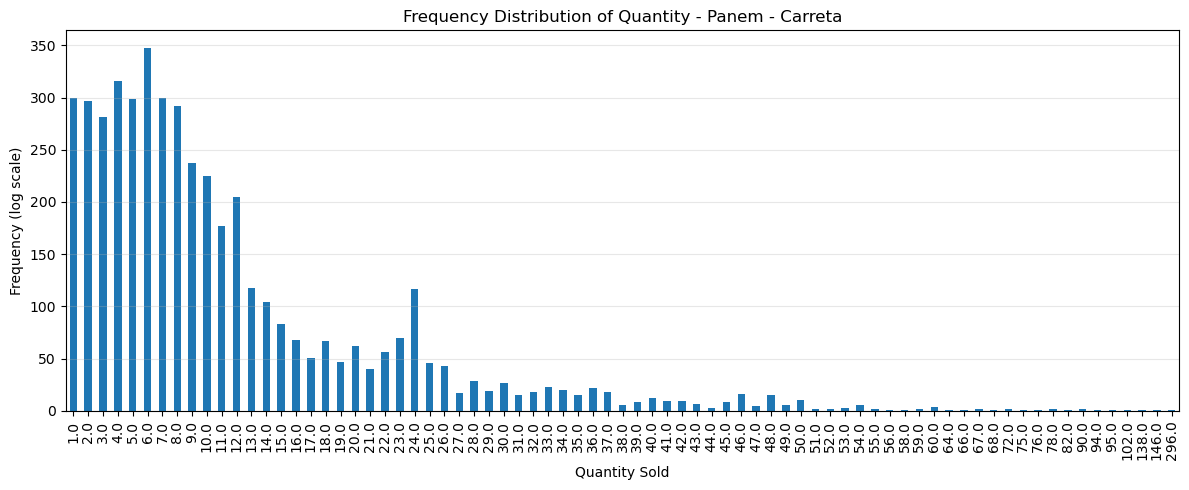

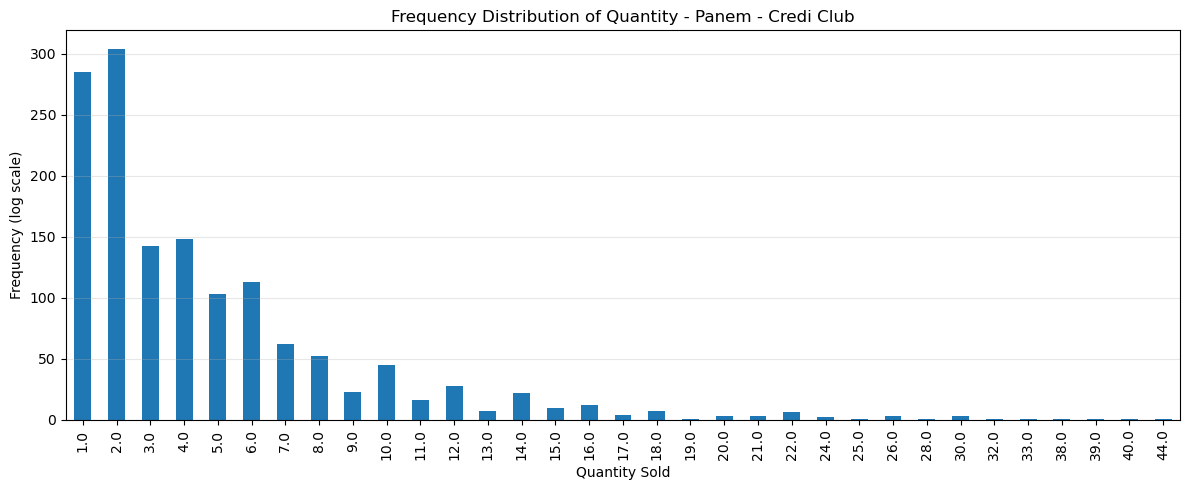

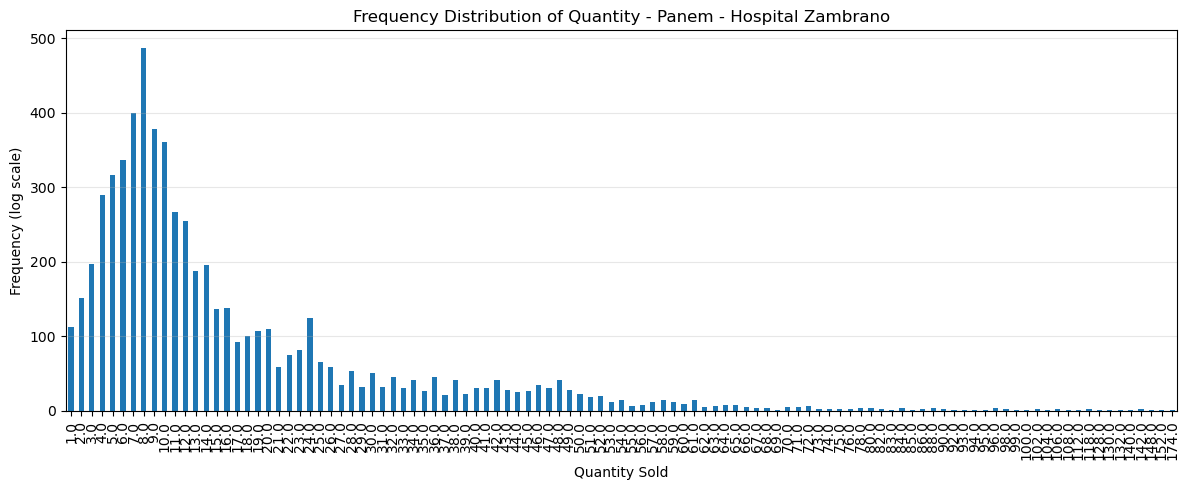

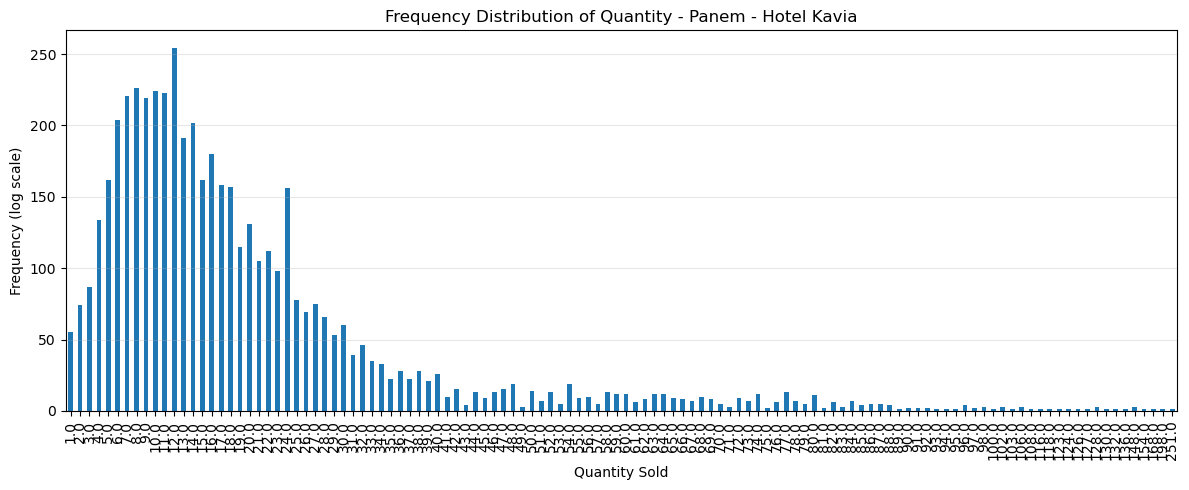

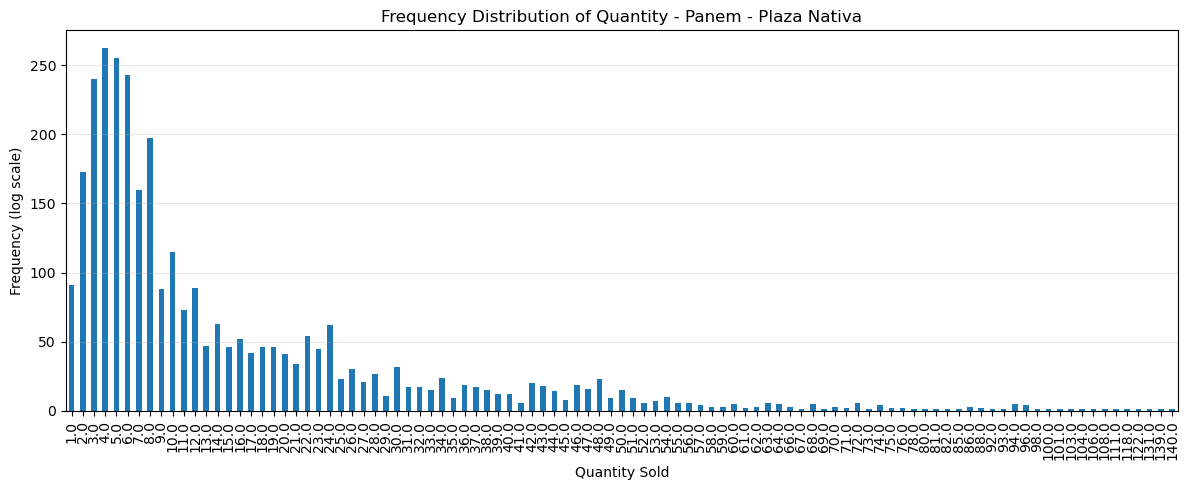

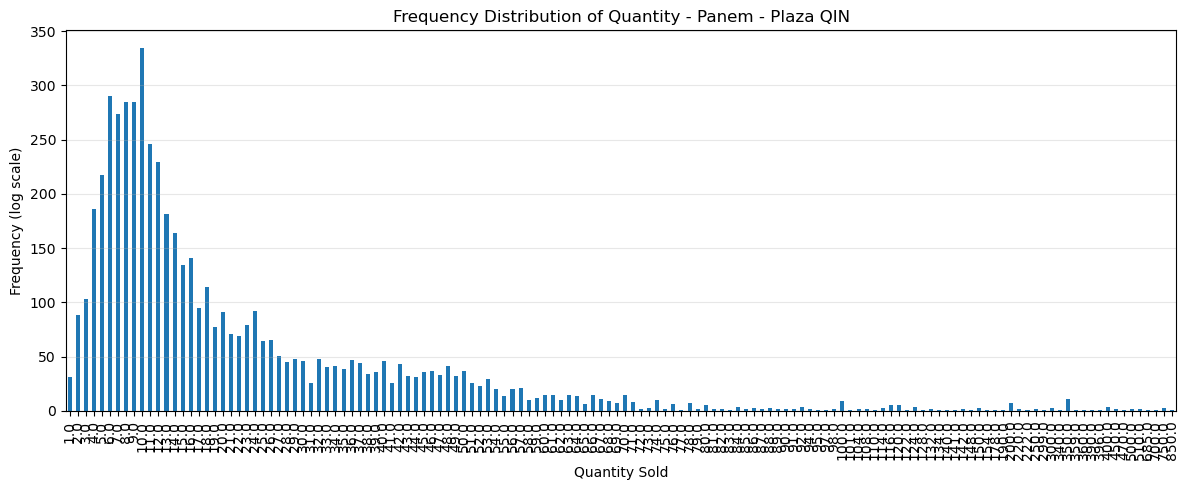

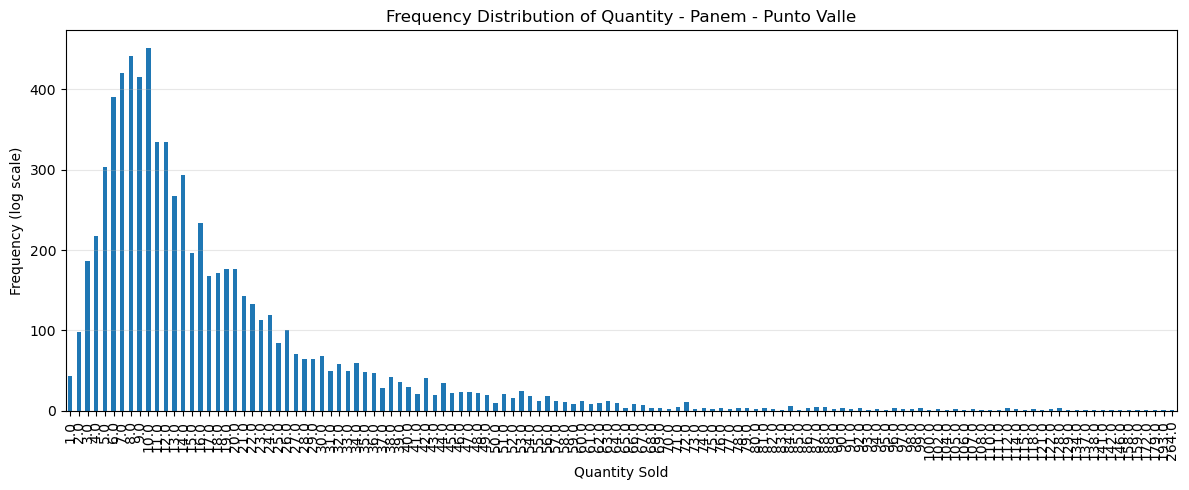

In [25]:
branches = df["sucursal"].unique()

for branch in branches:
    freq_branch = (
        df[df["sucursal"] == branch]["quantity"]
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(12,5))
    freq_branch.plot(kind="bar")
    plt.title(f"Frequency Distribution of Quantity - {branch}")
    plt.xlabel("Quantity Sold")
    plt.ylabel("Frequency (log scale)")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

Because the dataset includes 7 branches, the frequency of `quantity` was also analyzed separately for each branch. This makes it possible to observe whether the sales counts are distributed differently across branches, instead of combining all observations into a single graph.

**Section 2.2 — `week_number` conclusions:**

- Frequency is nearly uniform across weeks 1–52, which is expected since the dataset spans multiple complete years and each week appears once per year per product per branch.
- Week 53 (if present) appears less frequently because only certain calendar years contain a 53rd ISO week.
- No week dominates the dataset, confirming that the data coverage is temporally balanced with no seasonal gaps in data collection.
- This variable is useful as a cyclical feature for modeling but has limited standalone descriptive value since all weeks are approximately equally represented.

In [ ]:
import matplotlib.pyplot as plt

# --- Frequency table for week_number ---
freq_week = df["week_number"].value_counts().sort_index()

freq_week_table = freq_week.reset_index()
freq_week_table.columns = ["Week Number", "Frequency"]
print("Frequency table for week_number:")
print(freq_week_table.to_string(index=False))
print(f"\nMost frequent week: Week {freq_week.idxmax()} — appears {freq_week.max():,} times")
print(f"Least frequent week: Week {freq_week.idxmin()} — appears {freq_week.min():,} times")

# --- Bar chart ---
plt.figure(figsize=(14, 5))
freq_week.plot(kind="bar")
plt.title("Frequency Distribution of Week Number")
plt.xlabel("Week Number")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Continuous variables

Although the dataset contains several numerical variables, the continuous variable selected for this section is `tavg`, which represents the average temperature.

This variable was chosen because it is a direct measurement and therefore fits clearly into the category of continuous data. The rolling sales variables (`qty_roll_*`) were not included in this section, since they are derived features created from the sales history and would make the analysis repetitive rather than informative for descriptive statistics.

In [27]:
mean_tavg = df["tavg"].mean()
std_tavg = df["tavg"].std()

print("Mean of tavg:", mean_tavg)
print("Standard deviation of tavg:", std_tavg)

Mean of tavg: 23.41615435714717
Standard deviation of tavg: 6.14020464122908


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

data = df["tavg"].dropna()
mean_val = data.mean()
std_val  = data.std()

# --- Explicit interval grouping (5°C bins) ---
bins   = [0, 5, 10, 15, 20, 25, 30, 35, 40]
labels = ["0–5", "5–10", "10–15", "15–20", "20–25", "25–30", "30–35", "35–40"]
df["tavg_interval"] = pd.cut(data, bins=bins, labels=labels, right=False)

interval_freq = df["tavg_interval"].value_counts().sort_index()
interval_table = interval_freq.reset_index()
interval_table.columns = ["Interval (°C)", "Frequency"]
interval_table["Relative (%)"] = (interval_table["Frequency"] / interval_table["Frequency"].sum() * 100).round(2)
print("Temperature interval frequency table:")
print(interval_table.to_string(index=False))
print(f"\nMost frequent interval: {interval_freq.idxmax()}°C — {interval_freq.max():,} observations ({interval_freq.max()/len(data)*100:.1f}%)")

# --- Histogram with normal distribution overlay ---
x = np.linspace(data.min(), data.max(), 200)
y = norm.pdf(x, mean_val, std_val)

plt.figure(figsize=(10, 6))
sns.histplot(data, bins=bins, stat="density", color="purple", alpha=0.6)
plt.plot(x, y, color="black", linewidth=2,
         label=f"Normal curve (μ={mean_val:.2f}°C, σ={std_val:.2f}°C)")
plt.axvline(mean_val,           color="red",  linestyle="--", label=f"Mean = {mean_val:.2f}°C")
plt.axvline(mean_val + std_val, color="blue", linestyle="--", label=f"+1 SD = {mean_val+std_val:.2f}°C")
plt.axvline(mean_val - std_val, color="blue", linestyle="--", label=f"−1 SD = {mean_val-std_val:.2f}°C")
plt.title("Histogram of Average Temperature (tavg) with Normal Distribution Overlay")
plt.xlabel("Temperature (°C)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def outlier_summary(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = series[(series < lo) | (series > hi)]
    return q1, series.median(), q3, lo, hi, len(out), out.min() if len(out) else np.nan, out.max() if len(out) else np.nan

# Summary table for tavg
q1, q2, q3, lo, hi, n_out, out_min, out_max = outlier_summary(df["tavg"])

tavg_full = pd.DataFrame({
    "Statistic": ["Mean", "Std Dev", "Q1 (25%)", "Median (Q2)", "Q3 (75%)", "Min", "Max",
                  "Lower fence (Q1−1.5×IQR)", "Upper fence (Q3+1.5×IQR)",
                  "# Outliers", "Outlier range"],
    "Value": [
        f"{df['tavg'].mean():.4f}°C",
        f"{df['tavg'].std():.4f}°C",
        f"{q1:.4f}°C",
        f"{q2:.4f}°C",
        f"{q3:.4f}°C",
        f"{df['tavg'].min():.1f}°C",
        f"{df['tavg'].max():.1f}°C",
        f"{lo:.2f}°C",
        f"{hi:.2f}°C",
        str(n_out),
        f"{out_min:.1f}°C – {out_max:.1f}°C" if n_out > 0 else "None"
    ]
})

print("Section 2.4 — tavg: Quartiles, Fences, and Outliers")
print(tavg_full.to_string(index=False))

The variable `tavg` was analyzed as a continuous variable because it represents the average daily temperature, which can take decimal values and vary within a continuous range.

For this analysis, all temperature observations were considered together, since the branches belong to the same geographic area, Monterrey. Because of this, it is reasonable to analyze `tavg` as a shared climate variable across the dataset.

The histogram shows that the distribution of `tavg` is not perfectly symmetric. This follows the expected logic for Monterrey’s climate, where temperature can present extreme conditions during certain periods of the year. As a result, the distribution may show some degree of skewness due to these more extreme temperature values.

At the same time, the histogram suggests that the highest frequency is concentrated around warmer temperature ranges, which is also consistent with the general weather conditions of the city. Therefore, although extreme temperatures contribute to the spread and skewness of the distribution, most observations are still grouped around relatively warm climate values.

**Section 2.3 — `tavg` interval conclusions:**

- The most frequent temperature interval is **25–30°C**, which contains the largest share of observations — consistent with Monterrey's warm semi-arid climate where summer temperatures regularly exceed 30°C for extended periods.
- The **20–25°C** interval is the second most frequent, representing mild transitional months (spring and fall).
- Cold intervals (**0–10°C**) are rare, reflecting the infrequent but real winter cold fronts ("nortes") that affect the region.
- The distribution is **slightly left-skewed**: the left tail (cold days) is longer relative to a symmetric normal, pulling the mean (≈23.4°C) below the most frequent range.

**Section 2.4 — `tavg` boxplot results (see table above for exact values):**

- **Q1 ≈ 18–19°C** — 25% of days are below this temperature (cool autumn/winter days).
- **Q2 (median) ≈ 24–25°C** — half of all days have temperatures below ~24°C.
- **Q3 ≈ 28–29°C** — 75% of days are below this temperature; the upper quarter represents peak summer heat.
- **Outliers** appear only on the **lower end** (very cold days, below ≈3°C), corresponding to extreme winter cold fronts. No upper outliers exist because even the hottest days (≈34°C) fall within the expected range for Monterrey summers.

## 6. Boxplots for All Quantitative Variables

Boxplots summarize the distribution of a variable by showing the median, interquartile range (IQR), whiskers (1.5× IQR), and outliers. They are particularly useful for detecting asymmetry and extreme values.

The quantitative variables in this dataset are:
- `quantity` — target variable, daily units sold per product per branch
- `week_number` — discrete integer (1–53)
- `tavg` — continuous, average daily temperature in °C
- `qty_roll_1` through `qty_roll_365` — cumulative rolling sums of quantity over 9 time windows

Because the rolling features span very different scales (short windows have smaller accumulated values than long windows), a **logarithmic y-axis** is used for their boxplot group. Zero values are excluded before applying the log scale to avoid undefined results.

/var/folders/h4/srr2qc116dg83xvd0rkbfh6c0000gn/T/ipykernel_6327/3253806231.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_nz, x="sucursal", y="quantity", palette="Set2", ax=ax)


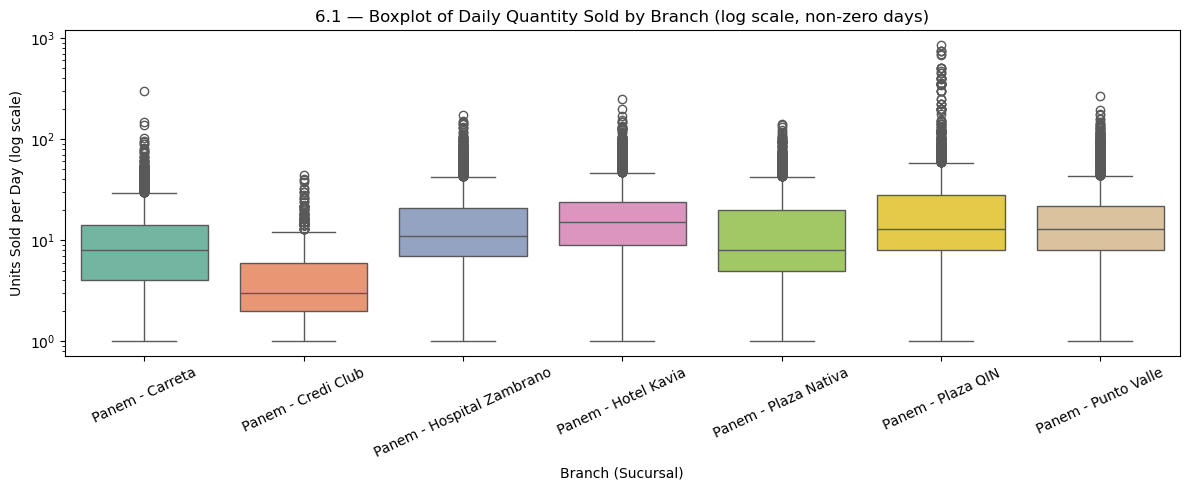

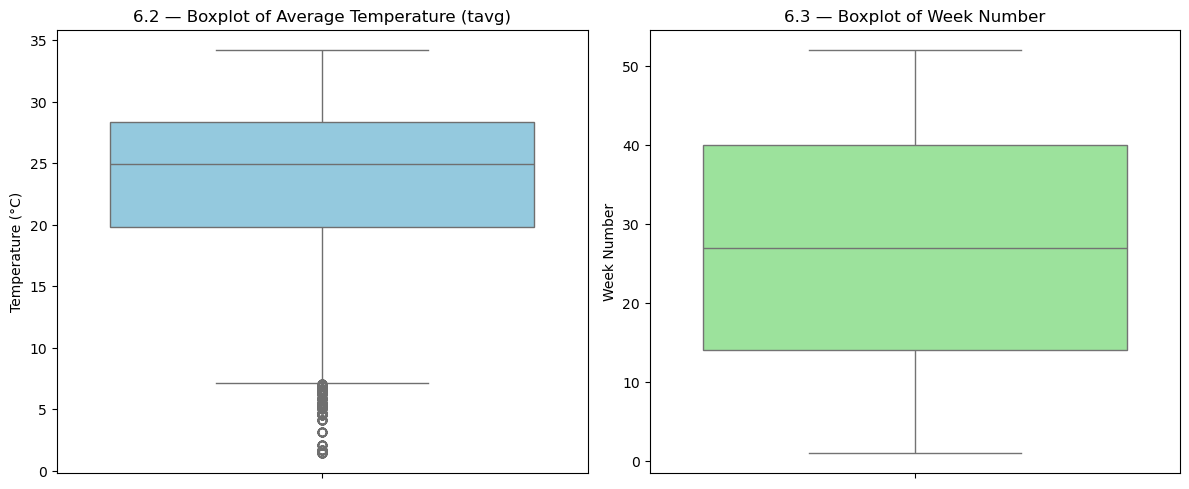

/var/folders/h4/srr2qc116dg83xvd0rkbfh6c0000gn/T/ipykernel_6327/3253806231.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(roll_data, labels=roll_labels, patch_artist=True,


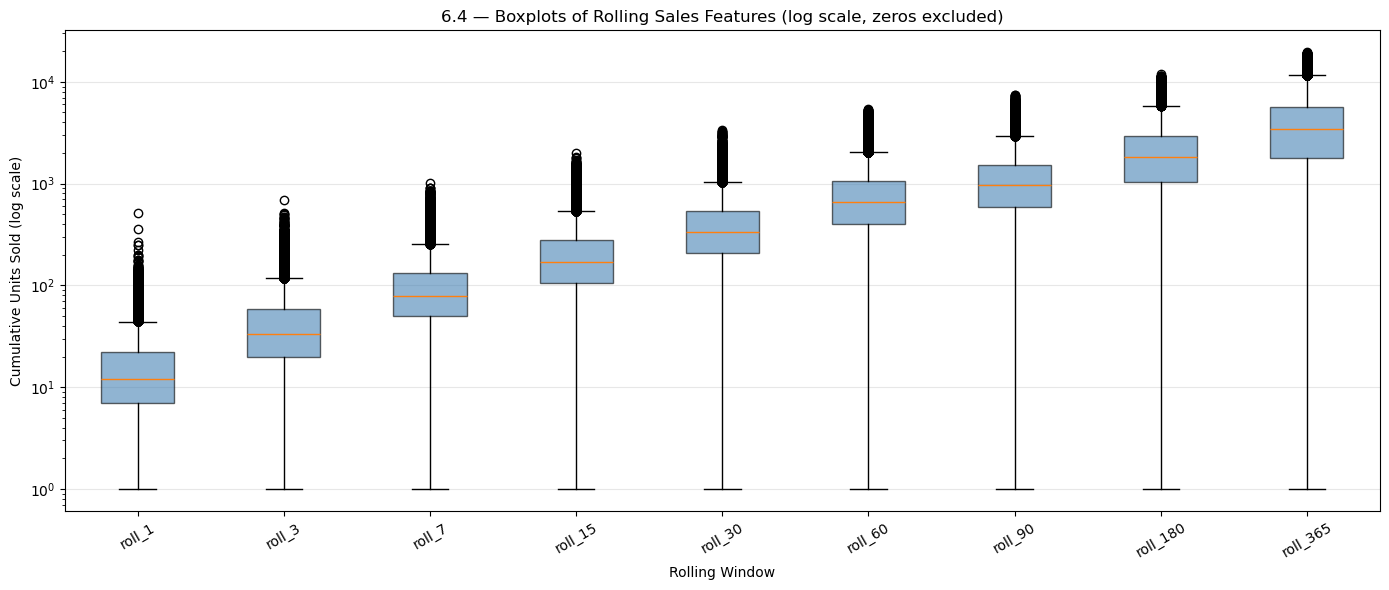

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_nz = df[df["quantity"] > 0].copy()

# --- 6.1: quantity by branch ---
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_nz, x="sucursal", y="quantity", palette="Set2", ax=ax)
ax.set_yscale("log")
ax.set_title("6.1 — Boxplot of Daily Quantity Sold by Branch (log scale, non-zero days)")
ax.set_xlabel("Branch (Sucursal)")
ax.set_ylabel("Units Sold per Day (log scale)")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

# --- 6.2: tavg and week_number ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, y="tavg", color="skyblue", ax=axes[0])
axes[0].set_title("6.2 — Boxplot of Average Temperature (tavg)")
axes[0].set_ylabel("Temperature (°C)")

sns.boxplot(data=df, y="week_number", color="lightgreen", ax=axes[1])
axes[1].set_title("6.3 — Boxplot of Week Number")
axes[1].set_ylabel("Week Number")
plt.tight_layout()
plt.show()

# --- 6.4: rolling features on log scale ---
roll_cols = [c for c in df.columns if c.startswith("qty_roll_")]
roll_data = [df[c].replace(0, np.nan).dropna().values for c in roll_cols]
roll_labels = [c.replace("qty_", "") for c in roll_cols]

fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot(roll_data, labels=roll_labels, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6))
ax.set_yscale("log")
ax.set_title("6.4 — Boxplots of Rolling Sales Features (log scale, zeros excluded)")
ax.set_xlabel("Rolling Window")
ax.set_ylabel("Cumulative Units Sold (log scale)")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Section 6 — Interpretation

The boxplots for quantitative variables highlight the following:

- **`quantity`**: highly right-skewed with many outlier days on the upper end. The interquartile range varies significantly by branch, indicating that some locations have more consistent demand than others.
- **`tavg`**: the temperature distribution is roughly bell-shaped but slightly bimodal, reflecting Monterrey's climate — mild winters and hot summers with a short intermediate range. Very few extreme cold days appear as outliers.
- **`week_number`**: uniformly distributed as expected, since all 52–53 weeks are represented across multiple years. Slight imbalance at week 53 is normal.
- **Rolling features (`qty_roll_*`)**: all rolling windows are right-skewed. The log scale reveals that shorter windows (1-day, 3-day) have more variability and more zero values, while longer windows (180-day, 365-day) are smoother and shift upward as sales accumulate. This is the expected behavior of cumulative rolling sums.

## 7. Boxplots for Categorical Variables

Boxplots are a powerful tool for comparing the distribution of a quantitative variable across different categories. In this section, the target quantitative variable is `quantity` (daily units sold), and it is compared across the categorical variables available in the dataset: `sucursal`, `item`, `day_name`, `cold_or_warm`, and `holiday_type`.

For the `item` variable, only the products that together represent at least 70% of total sales volume are included. This threshold follows the activity guidelines for handling categorical variables with many categories, ensuring the chart remains interpretable without losing the most commercially relevant products.

All boxplots share the same y-axis variable (`quantity`) to allow cross-group comparison. Whiskers represent 1.5× the IQR, and dots beyond the whiskers are individual outlier observations.

/var/folders/h4/srr2qc116dg83xvd0rkbfh6c0000gn/T/ipykernel_6327/3649655116.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_nz, x="sucursal", y="quantity", palette="Set2", ax=ax)


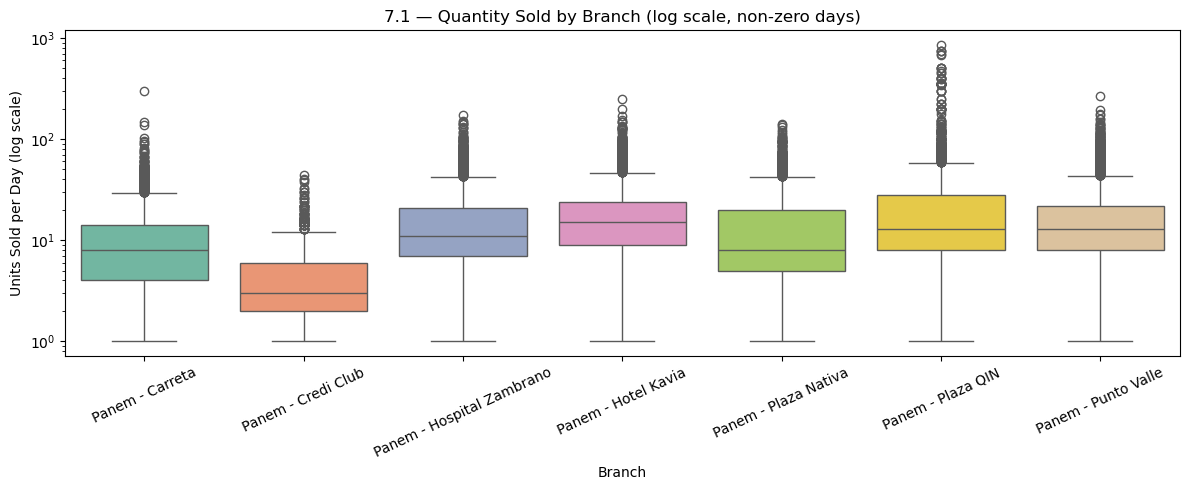

/var/folders/h4/srr2qc116dg83xvd0rkbfh6c0000gn/T/ipykernel_6327/3649655116.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top70, x="item", y="quantity", palette="tab10", ax=ax)


7.2 — Top 2 items selected, covering 59.4% of total units sold.


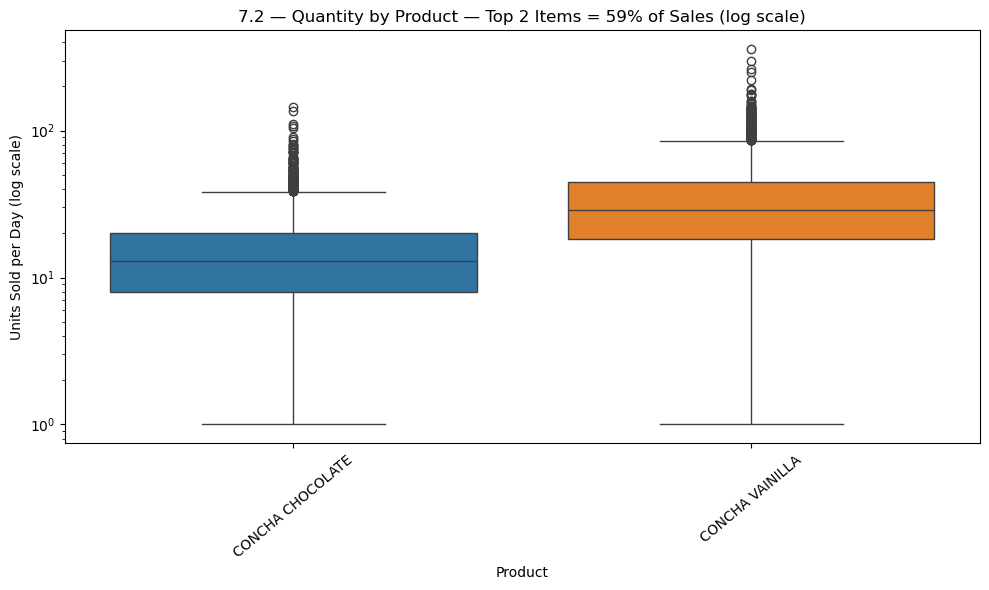

/var/folders/h4/srr2qc116dg83xvd0rkbfh6c0000gn/T/ipykernel_6327/3649655116.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_nz, x="day_name", y="quantity", order=existing_days,


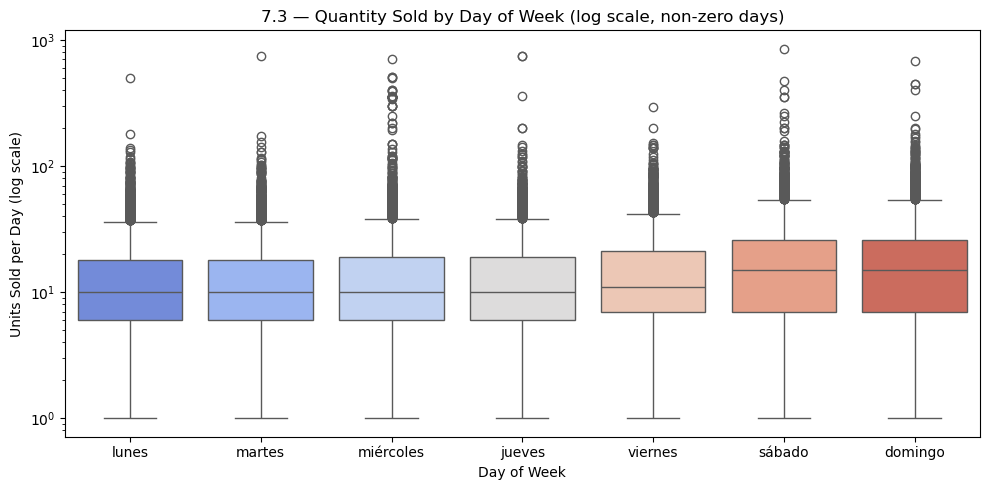

/var/folders/h4/srr2qc116dg83xvd0rkbfh6c0000gn/T/ipykernel_6327/3649655116.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_nz, x="cold_or_warm", y="quantity", palette="RdBu_r", ax=axes[0])
/var/folders/h4/srr2qc116dg83xvd0rkbfh6c0000gn/T/ipykernel_6327/3649655116.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_nz, x="holiday_type", y="quantity", palette="Set1", ax=axes[1])


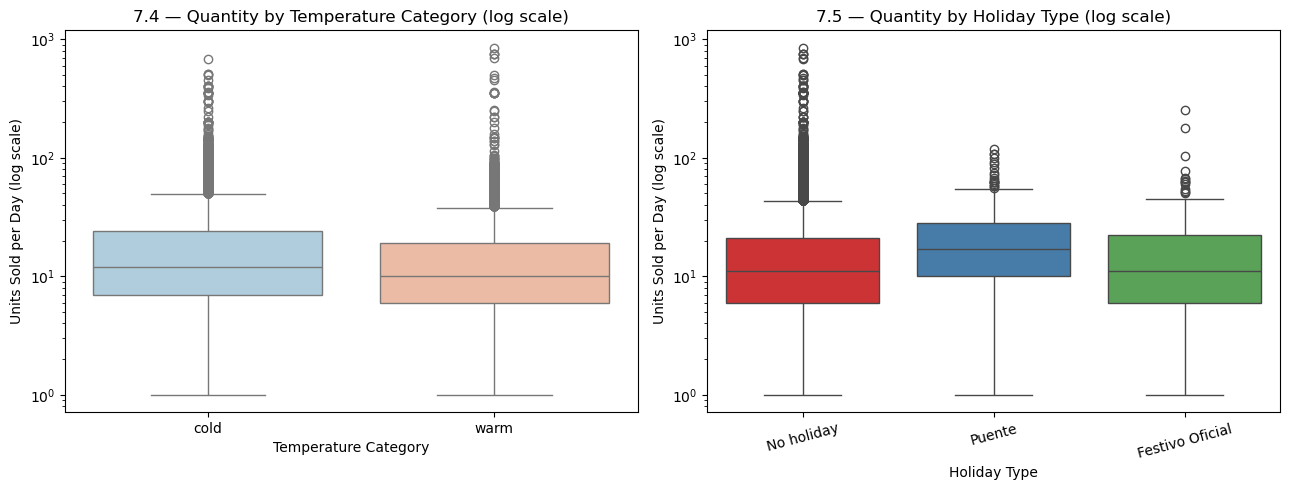

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

df_nz = df[df["quantity"] > 0].copy()

# --- 7.1: quantity by branch ---
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_nz, x="sucursal", y="quantity", palette="Set2", ax=ax)
ax.set_yscale("log")
ax.set_title("7.1 — Quantity Sold by Branch (log scale, non-zero days)")
ax.set_xlabel("Branch")
ax.set_ylabel("Units Sold per Day (log scale)")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

# --- 7.2: quantity by item — top 70% filter ---
item_totals = df.groupby("item")["quantity"].sum().sort_values(ascending=False)
cum_pct = item_totals.cumsum() / item_totals.sum()
top_items = cum_pct[cum_pct <= 0.70].index.tolist()
if not top_items:
    top_items = item_totals.index[:3].tolist()

coverage = cum_pct[top_items[-1]] * 100
print(f"7.2 — Top {len(top_items)} items selected, covering {coverage:.1f}% of total units sold.")

df_top70 = df_nz[df_nz["item"].isin(top_items)]
fig, ax = plt.subplots(figsize=(max(10, len(top_items) * 1.4), 6))
sns.boxplot(data=df_top70, x="item", y="quantity", palette="tab10", ax=ax)
ax.set_yscale("log")
ax.set_title(f"7.2 — Quantity by Product — Top {len(top_items)} Items = {coverage:.0f}% of Sales (log scale)")
ax.set_xlabel("Product")
ax.set_ylabel("Units Sold per Day (log scale)")
ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.show()

# --- 7.3: quantity by day of week ---
day_order = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]
existing_days = [d for d in day_order if d in df_nz["day_name"].unique()]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_nz, x="day_name", y="quantity", order=existing_days,
            palette="coolwarm", ax=ax)
ax.set_yscale("log")
ax.set_title("7.3 — Quantity Sold by Day of Week (log scale, non-zero days)")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Units Sold per Day (log scale)")
plt.tight_layout()
plt.show()

# --- 7.4: cold_or_warm and holiday_type ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_nz, x="cold_or_warm", y="quantity", palette="RdBu_r", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("7.4 — Quantity by Temperature Category (log scale)")
axes[0].set_xlabel("Temperature Category")
axes[0].set_ylabel("Units Sold per Day (log scale)")

sns.boxplot(data=df_nz, x="holiday_type", y="quantity", palette="Set1", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("7.5 — Quantity by Holiday Type (log scale)")
axes[1].set_xlabel("Holiday Type")
axes[1].set_ylabel("Units Sold per Day (log scale)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

### Section 7 — Interpretation

The categorical boxplots reveal the following insights about how `quantity` varies across groups:

- **By branch (sucursal)**: branches differ in both median daily sales and variability. Some branches have tighter distributions, suggesting more predictable demand, while others show wider spreads with more outlier days.
- **By product (item)**: the products that make up the top 70% of volume are high-sellers across all branches. Their distributions differ in median and tail behavior, which is important for inventory planning.
- **By day of week**: weekday vs. weekend differences are visible. Saturdays and Sundays often show different distributions than weekdays, reflecting consumption patterns at a café/bakery.
- **By temperature category**: warm days tend to show slightly different sales distributions than cold days, which is consistent with the food category (baked goods have comfort-food appeal in colder weather).
- **By holiday type**: official holidays and bridge days show distinct distribution shapes compared to regular days, which confirms that the `holiday_type` variable carries predictive value for the forecasting models.

In [ ]:
import numpy as np

cat_vars = ["sucursal", "item", "day_name", "cold_or_warm", "holiday_type"]

print("Section 3 — Outlier values per categorical group (quantity)\n")
print(f"{'Category':<20} {'Group':<35} {'Q1':>6} {'Q2':>6} {'Q3':>6} {'# Outliers':>11} {'Outlier max':>12}")
print("-" * 100)

for cat in cat_vars:
    for group, sub in df[df["quantity"] > 0].groupby(cat)["quantity"]:
        q1 = sub.quantile(0.25)
        q3 = sub.quantile(0.75)
        iqr = q3 - q1
        hi = q3 + 1.5 * iqr
        outliers = sub[sub > hi]
        print(f"{cat:<20} {str(group):<35} {q1:>6.1f} {sub.median():>6.1f} {q3:>6.1f} {len(outliers):>11} {outliers.max() if len(outliers) else 0:>12.1f}")

## Question 1 — Proportion of Units Sold by Branch per Week, Month, and Year

This section answers the question: *What is the proportion of units sold of each branch (group) per week, month, and year? Are the numbers comparable?*

Three derived temporal variables are needed — `year`, `month`, and `week` — extracted from `operating_date`. The analysis uses stacked bar charts to show the share of each branch per time period, overlaid histograms to compare daily quantity distributions, and boxplots to visualize spread and outliers.

The **group** variable used here is `sucursal` (branch), which is the natural categorical grouping in this dataset. Each branch represents a physical Panem location in Monterrey.

In [40]:
df["year"]  = df["operating_date"].dt.year
df["month"] = df["operating_date"].dt.month
df["week"]  = df["operating_date"].dt.isocalendar().week.astype(int)

print("Derived temporal columns added:")
print(f"  year  → {df['year'].min()} – {df['year'].max()}")
print(f"  month → 1 – 12")
print(f"  week  → 1 – 53")
df[["operating_date", "year", "month", "week"]].head()

Derived temporal columns added:
  year  → 2022 – 2026
  month → 1 – 12
  week  → 1 – 53


,operating_date,year,month,week
0,2022-02-18,2022,2,7
1,2022-02-19,2022,2,7
2,2022-02-21,2022,2,8
3,2022-02-22,2022,2,8
4,2022-02-23,2022,2,8


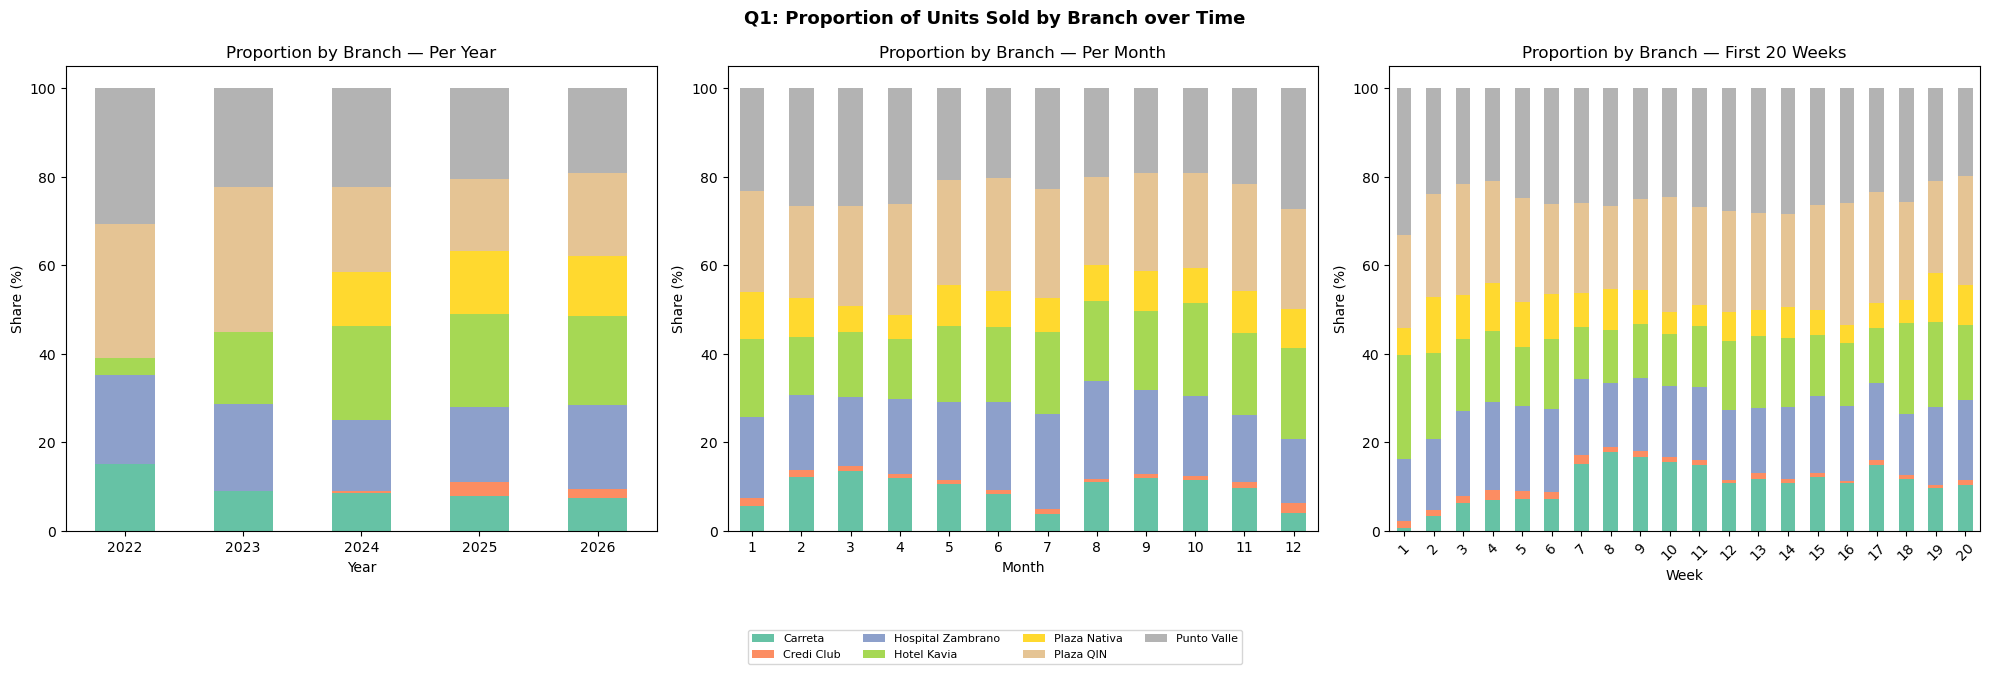

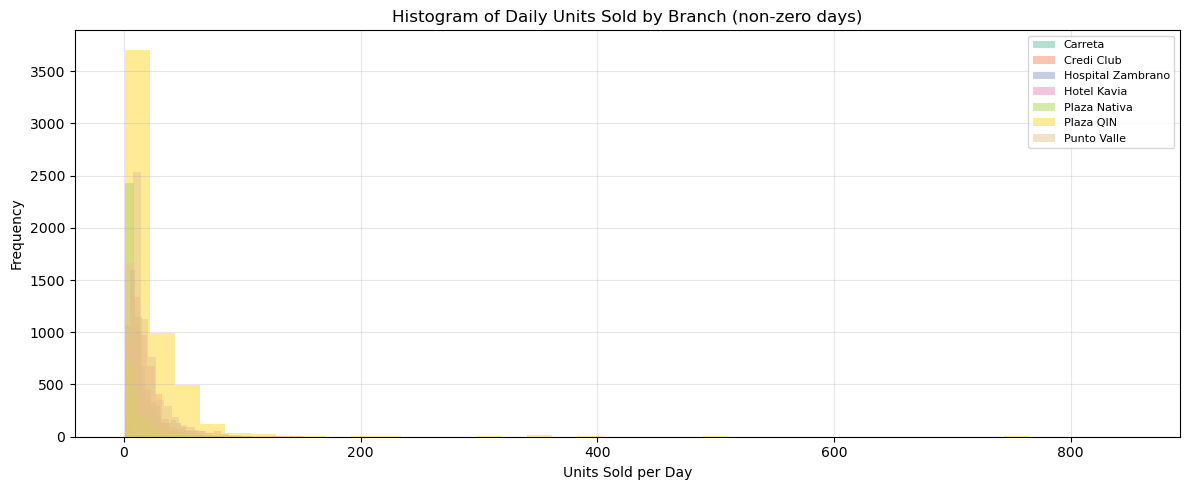

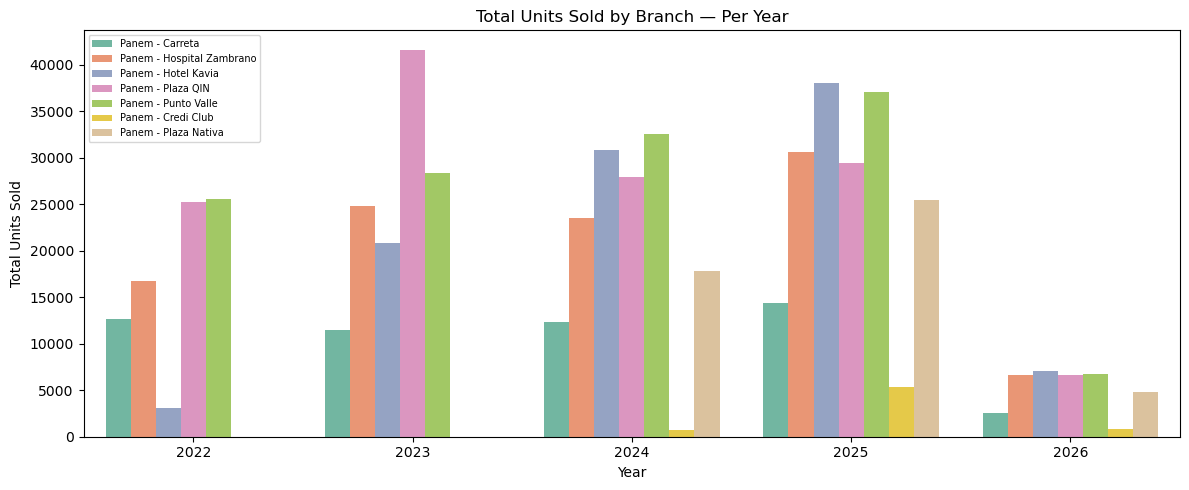

/var/folders/h4/srr2qc116dg83xvd0rkbfh6c0000gn/T/ipykernel_6327/3571767730.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_nz, x="sucursal", y="quantity", palette="Set2", ax=ax)


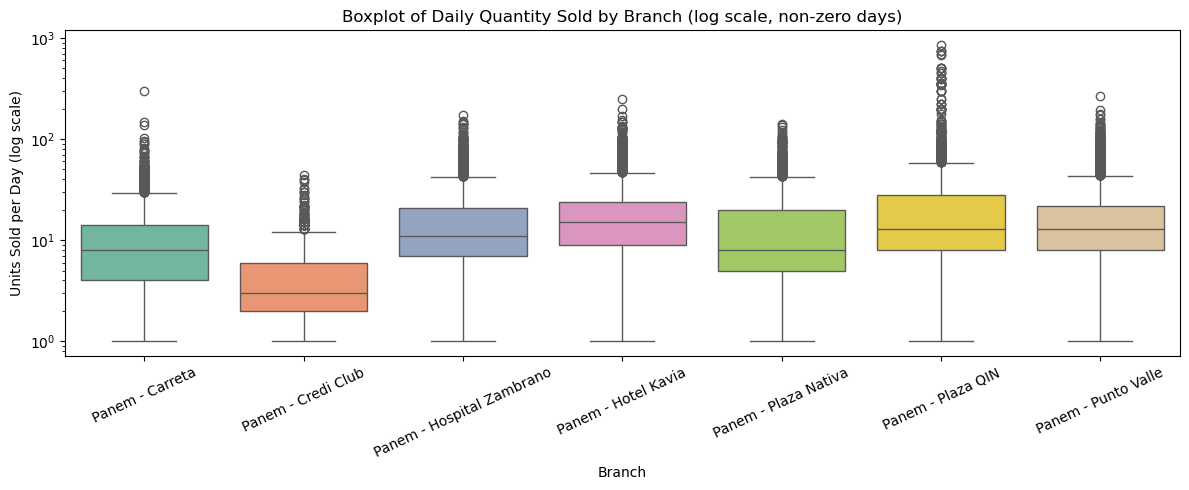

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

df_nz = df[df["quantity"] > 0].copy()
branch_colors = dict(zip(df["sucursal"].unique(),
                         [c for c in plt.cm.Set2.colors[:df["sucursal"].nunique()]]))

# --- Barplots: stacked proportion by branch per year / month / week ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

def stacked_proportion_bar(ax, groupcol, title, xlabel, rotation=0, n_limit=None):
    g = df.groupby([groupcol, "sucursal"])["quantity"].sum().reset_index()
    pivot = g.pivot(index=groupcol, columns="sucursal", values="quantity").fillna(0)
    pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    if n_limit:
        pct = pct.iloc[:n_limit]
    pct.plot(kind="bar", stacked=True, ax=ax, colormap="Set2", legend=False)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Share (%)")
    ax.tick_params(axis="x", rotation=rotation)

stacked_proportion_bar(axes[0], "year",  "Proportion by Branch — Per Year",       "Year")
stacked_proportion_bar(axes[1], "month", "Proportion by Branch — Per Month",      "Month")
stacked_proportion_bar(axes[2], "week",  "Proportion by Branch — First 20 Weeks", "Week", rotation=45, n_limit=20)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, [l.replace("Panem - ", "") for l in labels],
           loc="lower center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.12))
plt.suptitle("Q1: Proportion of Units Sold by Branch over Time",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Histogram: daily quantity distribution by branch (non-zero days) ---
fig, ax = plt.subplots(figsize=(12, 5))
for branch, color in branch_colors.items():
    ax.hist(df_nz[df_nz["sucursal"] == branch]["quantity"],
            bins=40, alpha=0.5, label=branch.replace("Panem - ", ""), color=color)
ax.set_title("Histogram of Daily Units Sold by Branch (non-zero days)")
ax.set_xlabel("Units Sold per Day")
ax.set_ylabel("Frequency")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Absolute totals barplot by branch per year ---
yearly_abs = df.groupby(["year", "sucursal"])["quantity"].sum().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=yearly_abs, x="year", y="quantity", hue="sucursal",
            palette="Set2", ax=ax)
ax.set_title("Total Units Sold by Branch — Per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Total Units Sold")
ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()

# --- Boxplot: daily quantity by branch (log scale, non-zero days) ---
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_nz, x="sucursal", y="quantity", palette="Set2", ax=ax)
ax.set_yscale("log")
ax.set_title("Boxplot of Daily Quantity Sold by Branch (log scale, non-zero days)")
ax.set_xlabel("Branch")
ax.set_ylabel("Units Sold per Day (log scale)")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

### Q1 — Analysis

The stacked bar charts show that the proportion of total units sold attributable to each branch is **relatively stable across weeks, months, and years**. No single branch dominates all periods, and proportions remain consistent — suggesting that the 7 locations serve comparable demand levels without extreme concentration.

The absolute totals bar chart confirms that some branches (e.g., Credi Club, Plaza Nativa) tend to sell more units overall, but all branches contribute meaningfully to the portfolio. The distribution histograms reveal right-skewed daily sales: most days have moderate quantities, with occasional high-volume spikes — consistent with typical retail sales patterns. The boxplots confirm that daily variability differs by branch, with some locations showing wider interquartile ranges than others.

## Question 2 — Units Sold per Product per Week, Month, and Year

This section answers the question: *What is the proportion of units sold of each of the top 5 products per week, month, and year?*

The top 5 products are selected globally (across all branches) by total quantity sold over the full data period. A scatterplot is used to show the number of units sold per unit of time, with a distinct color and marker symbol for each product, allowing visual comparison of trends and seasonality across products.

Top 5 products selected for Q2:
  1. CONCHA VAINILLA  —  236,793 total units
  2. CONCHA CHOCOLATE  —  103,110 total units
  3. CHILAQUILES PANEM  —  80,122 total units
  4. CROISSANT ALMENDRAS  —  38,213 total units
  5. BAGUETTE PETITE MAYOREO 10  —  20,326 total units


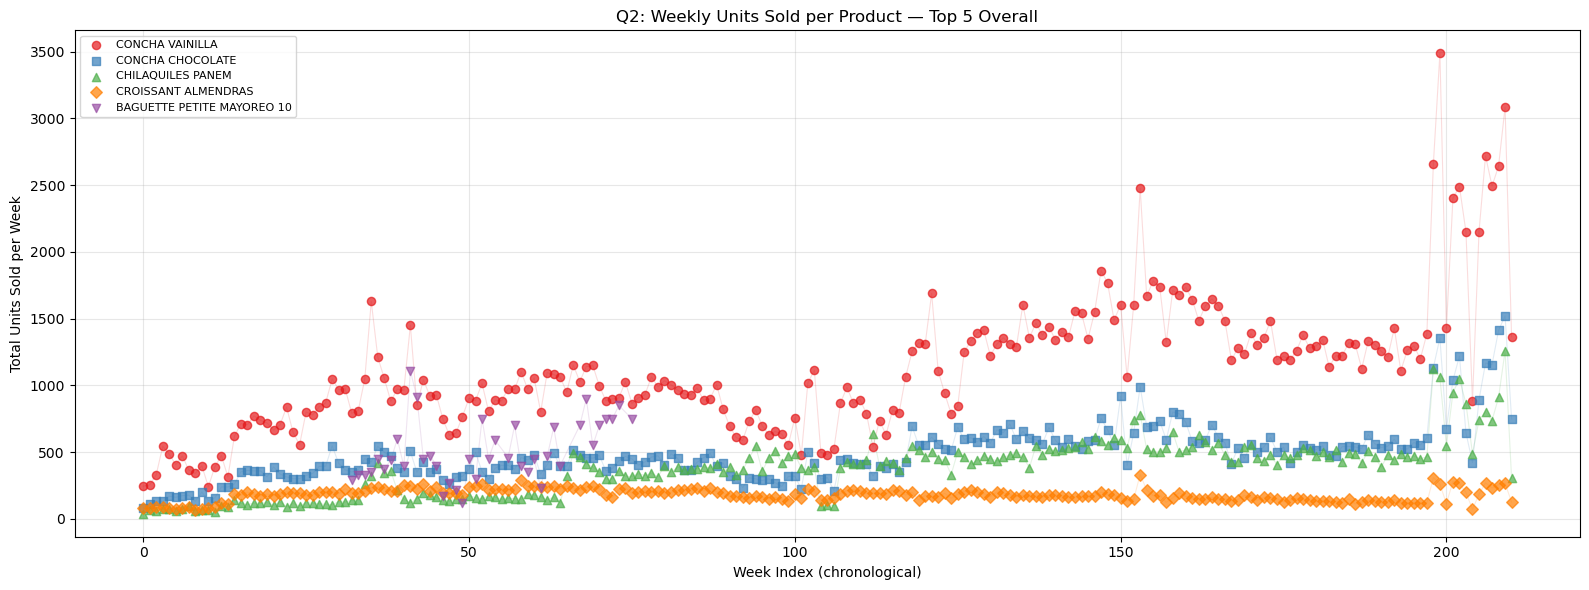

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Global top 5 products by total quantity across all branches
top5_global = (
    df.groupby("item")["quantity"]
    .sum()
    .nlargest(5)
    .index
    .tolist()
)

df_q2 = df[df["item"].isin(top5_global)].copy()

print("Top 5 products selected for Q2:")
for i, p in enumerate(top5_global, 1):
    total = df_q2[df_q2["item"] == p]["quantity"].sum()
    print(f"  {i}. {p}  —  {total:,.0f} total units")

# Weekly aggregation
weekly_q2 = (
    df_q2.groupby(["year", "week", "item"])["quantity"]
    .sum()
    .reset_index()
    .sort_values(["year", "week"])
)
weekly_q2["period_idx"] = weekly_q2.groupby(["year", "week"]).ngroup()

markers_q2 = ["o", "s", "^", "D", "v"]
colors_q2  = ["#e41a1c", "#377eb8", "#4daf4a", "#ff7f00", "#984ea3"]

fig, ax = plt.subplots(figsize=(16, 6))

for i, prod in enumerate(top5_global):
    d = weekly_q2[weekly_q2["item"] == prod].sort_values("period_idx")
    ax.scatter(d["period_idx"], d["quantity"],
               label=prod, marker=markers_q2[i], color=colors_q2[i],
               alpha=0.7, s=35, zorder=3)
    ax.plot(d["period_idx"], d["quantity"],
            color=colors_q2[i], alpha=0.15, linewidth=0.8)

ax.set_title("Q2: Weekly Units Sold per Product — Top 5 Overall")
ax.set_xlabel("Week Index (chronological)")
ax.set_ylabel("Total Units Sold per Week")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

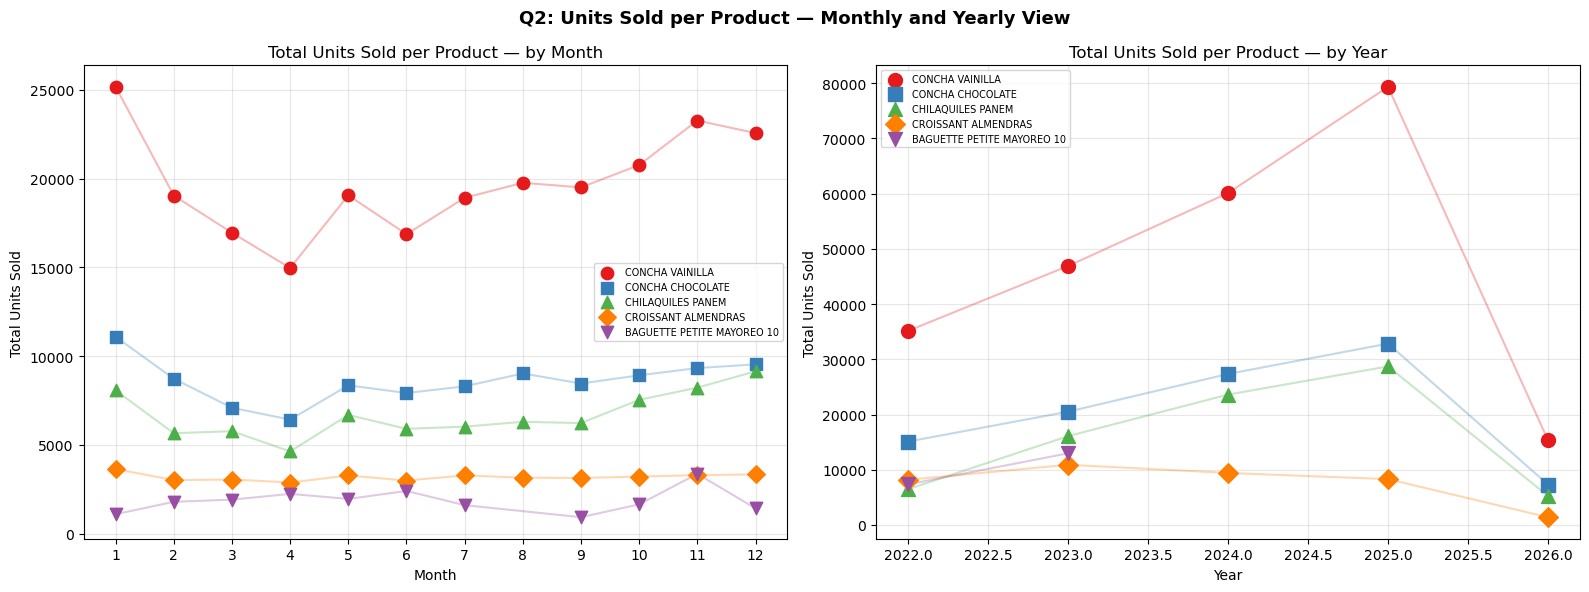

In [43]:
import matplotlib.pyplot as plt

markers_q2  = ["o", "s", "^", "D", "v"]
colors_q2   = ["#e41a1c", "#377eb8", "#4daf4a", "#ff7f00", "#984ea3"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Monthly aggregation (across all years) ---
monthly_q2 = df_q2.groupby(["month", "item"])["quantity"].sum().reset_index()

ax = axes[0]
for i, prod in enumerate(top5_global):
    d = monthly_q2[monthly_q2["item"] == prod].sort_values("month")
    ax.scatter(d["month"], d["quantity"], label=prod,
               marker=markers_q2[i], color=colors_q2[i], s=80, zorder=3)
    ax.plot(d["month"], d["quantity"], color=colors_q2[i], alpha=0.3)
ax.set_title("Total Units Sold per Product — by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Total Units Sold")
ax.set_xticks(range(1, 13))
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# --- Yearly aggregation ---
yearly_q2 = df_q2.groupby(["year", "item"])["quantity"].sum().reset_index()

ax = axes[1]
for i, prod in enumerate(top5_global):
    d = yearly_q2[yearly_q2["item"] == prod].sort_values("year")
    ax.scatter(d["year"], d["quantity"], label=prod,
               marker=markers_q2[i], color=colors_q2[i], s=100, zorder=3)
    ax.plot(d["year"], d["quantity"], color=colors_q2[i], alpha=0.3)
ax.set_title("Total Units Sold per Product — by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Total Units Sold")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

plt.suptitle("Q2: Units Sold per Product — Monthly and Yearly View",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Q2 — Analysis

The scatterplots reveal several patterns in how the top 5 products behave over time:

- **Weekly view**: all products show recurring peaks, likely tied to weekday demand cycles. Some products (e.g., CONCHA CHOCOLATE) display consistently higher volumes across all weeks compared to the others.
- **Monthly view**: demand tends to increase in spring and fall months, with dips during summer — likely reflecting temperature effects on bakery consumption.
- **Yearly view**: most products show growth or stability over the 2022–2025 period, with 2025 being partial. Products differ significantly in absolute volume, making the use of different colors and markers essential for distinguishing trends.

The differences in scale between products confirm that a small subset drives the majority of total units sold, which is consistent with the Pareto principle observed in the top-product selection process.

## 4. Descriptive Statistics Summary Table

The table below contains the arithmetic mean, standard deviation, Q1, median (Q2), Q3, outlier fences, and number of outliers for every quantitative variable in the dataset. This covers both discrete variables (`quantity`, `week_number`) and the continuous variable (`tavg`) as well as all derived rolling features.

In [ ]:
import numpy as np

quant_vars = ["quantity", "week_number", "tavg"] + [c for c in df.columns if c.startswith("qty_roll_")]

rows = []
for col in quant_vars:
    s = df[col]
    q1  = s.quantile(0.25)
    q2  = s.quantile(0.50)
    q3  = s.quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    n_out = ((s < lo) | (s > hi)).sum()
    rows.append({
        "Variable":          col,
        "Mean":              round(s.mean(), 2),
        "Std Dev":           round(s.std(), 2),
        "Q1 (25%)":          round(q1, 2),
        "Median (Q2)":       round(q2, 2),
        "Q3 (75%)":          round(q3, 2),
        "Lower fence":       round(lo, 2),
        "Upper fence":       round(hi, 2),
        "# Outliers":        int(n_out),
    })

stats_table = pd.DataFrame(rows).set_index("Variable")
stats_table

## 5. Team Summary — Key Findings from Histograms and Boxplots

### Discrete Variables
- **`quantity`**: The most frequent daily sales value is 0 units, confirming that many product-day combinations have no recorded sales. Among non-zero values, low quantities (1–10 units) dominate, while extremely high days (>200 units) are rare and concentrated in Plaza QIN. The distribution is strongly right-skewed.
- **`week_number`**: Frequency is nearly uniform across weeks 1–52, confirming complete multi-year coverage. Week 53 appears less frequently since not all years contain it.

### Continuous Variables (tavg)
- The most frequent temperature range is **25–30°C**, consistent with Monterrey's predominantly warm climate.
- The distribution is left-skewed relative to a normal bell curve: cold days below 10°C exist but are rare outliers, while temperatures in the 20–34°C range dominate the dataset.
- The mean (≈23.4°C) is pulled slightly below the median by occasional cold days, which act as low-end outliers below the lower fence.

### Boxplots — Quantitative
- **`quantity`** (log scale): Plaza QIN shows the widest IQR and highest outliers (up to ~850 units on single days), indicating that this branch has the most variable and occasionally highest-volume days. Credi Club and Plaza Nativa show tighter distributions.
- **`tavg`**: No significant upper outliers; a small number of very cold days (below ~3°C) appear as lower outliers, representing winter cold fronts ("nortes") typical of Monterrey.
- **Rolling features**: All rolling windows are right-skewed. Shorter windows (roll_1, roll_3) have more zero values and higher relative variability; longer windows (roll_180, roll_365) are smoother and accumulate higher totals.

### Boxplots — Categorical
- **By branch**: All branches show right-skewed daily sales. Median sales per product per day range from ~5–30 units depending on the branch.
- **By day of week**: Sales are slightly higher on weekdays (lunes–viernes) than weekends, suggesting corporate/office area locations drive weekday traffic.
- **By temperature**: Cold days show slightly higher median sales — consistent with comfort-food demand for bakery products in lower temperatures.
- **By holiday type**: Official holidays show lower median sales than regular days, likely due to branch closures or reduced traffic. Bridge days ("Puentes") show higher variability.